In [1]:
import os, json, time, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
if OPENROUTER_API_KEY is None:
    raise ValueError("OPENROUTER_API_KEY is not set")

In [3]:
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY
)

In [4]:
df = pd.read_csv(r"F:\Thesis\project\403-vekalat\structured_questions_402.csv")
df.head(3)

,question_number,category,question,options
0,1,نامشخص,«الف» به وکالت از «ب»، ملک «ب» را به مبلغ معین...,1) درهرحالت، «الف» مکلف به استرداد ثمن دریافتی...
1,2,نامشخص,درباره «دلیل لبّی»، کدام مورد صحیح است؟,1) فقط باید اخذ به قدر متیقّن کرد. | 2) اصول ل...
2,3,نامشخص,کدام مورد نسبت به جرم اسیدپاشی، ممنوعیت مطلق ج...,1) آزادی مشروط | 2) تخفیف مجازات | 3) تعلیق اج...


In [5]:
def to_list(opts):
    if isinstance(opts, list): return opts
    if isinstance(opts, str):
        try:
            v = json.loads(opts)
            if isinstance(v, list): return v
        except Exception: pass
        for sep in ["|","؛",";","/","\\","،","\n"]:
            if sep in opts: return [x.strip() for x in opts.split(sep) if x.strip()]
        return [opts.strip()]
    return [str(opts)]

In [6]:
def render_numeric_options(opts):
    return "\n".join(f"{i+1}) {o}" for i, o in enumerate(opts))

In [7]:
def build_messages(question: str, options_text: str):
    return [
        {
            "role": "system",
            "content": (
                "# Iranian Legal MCQ Reasoning System\n"
                "You are a **senior Iranian lawyer and legal examiner** with deep expertise "
                "in Iranian statutory law.\n"
                "Your reasoning must reflect how a practicing lawyer thinks: "
                "precise, article-grounded, and conclusive.\n\n"

                "---\n"
                "## Task\n"
                "- Language: **Persian (فارسی)** for all reasoning and output.\n"
                "- Analyze the question as a legal professional and select the "
                "**single correct option (1–4)**.\n"
                "- You MUST follow the **exact 5-step reasoning structure** below.\n"
                "- **Critical E2P rule**: In steps 1–4, do NOT reveal which option is "
                "correct. Evaluate all options neutrally. Only in Step 5 may you name "
                "the correct answer for the first time.\n\n"

                "---\n"
                "## 5-Step Legal Reasoning Structure (MANDATORY)\n\n"

                "**گام ۱ — تحلیل موضوع (Issue Spotting)**\n"
                "Identify the precise legal issue(s) raised. What branch of law? "
                "What legal relationship or dispute?\n\n"

                "**گام ۲ — احصاء قواعد حاکم (Rule Identification)**\n"
                "State the exact article(s), law name(s), and legal principles governing "
                "this issue.\n"
                "Format: «ماده X قانون Y» or «اصل X قانون اساسی» — never vague references.\n\n"

                "**گام ۳ — تطبیق قاعده با گزینه‌ها (Neutral Application)**\n"
                "For each of the four options, state:\n"
                "(a) what the option claims, and\n"
                "(b) what the identified article(s) say about that claim.\n"
                "Do NOT label any option as correct or incorrect here. "
                "Analyze all four options purely and neutrally.\n\n"

                "**گام ۴ — تمییز گزینه‌ها (Critical Discrimination)**\n"
                "Based solely on the analysis in گام ۳, identify the specific legal defect "
                "in each option that diverges from the statutory text. "
                "Still do NOT announce the final answer — only expose the flaws.\n\n"

                "**گام ۵ — نتیجه‌گیری قضایی (Legal Conclusion)**\n"
                "This is the FIRST and ONLY place the correct answer is named.\n"
                "State which option is correct and the single controlling legal reason "
                "in one precise sentence.\n\n"

                "---\n"
                "## Confidence Scale\n"
                "- 5: Certain — explicit statutory text with no ambiguity.\n"
                "- 4: Strong — clear article support; minor interpretive variation possible.\n"
                "- 3: Moderate — standard interpretation; scholarly debate exists.\n"
                "- 2: Weak — genuine ambiguity; competing interpretations.\n"
                "- 1: Uncertain — insufficient statutory basis to distinguish options.\n\n"

                "---\n"
                "# =================== FEW-SHOT EXAMPLES ===================\n\n"

                "## Example 1 — Civil Law / Law of Inheritance\n"
                "User: سؤال: شخصی فوت کرده و وراث حین‌الفوت وی عبارت‌اند از عموی امّی، "
                "عمه امّی، عموی ابوینی و دو عمه ابوینی. ماترک او به کدام صورت تقسیم می‌شود؟\n"
                "گزینه‌ها:\n"
                "1) عمو و عمه امّی هرکدام یک‌ششم ماترک را می‌برند و مابقی، بین ابوینی‌ها "
                "به نسبت ذکور دو برابر اناث تقسیم می‌شود.\n"
                "2) وراث امّی یک‌سوم و وراث ابوینی دوسوم از ماترک را می‌برند و بین هر دسته، "
                "به صورت ذکور دو برابر اناث تقسیم می‌شود.\n"
                "3) عمو و عمه امّی مجموعاً یک‌ششم ماترک را می‌برند و بین آن‌ها بالسویه "
                "تقسیم می‌شود و دوسوم مابقی به عمو و عمه‌های ابوینی می‌رسد که ذکور دو برابر "
                "اناث ارث می‌برند.\n"
                "4) وراث امّی یک‌سوم و وراث ابی دوسوم ماترک را می‌برند و بین امّی‌ها، "
                "ذکور دو برابر اناث و بین ابوینی‌ها به صورت بالسویه تقسیم می‌شود.\n\n"
                "Assistant:\n"
                "**گام ۱ — تحلیل موضوع:**\n"
                "موضوع، نحوه تقسیم ارث در طبقه سوم (اعمام و اخوال) با اجتماع اعمام امّی "
                "و اعمام ابوینی است. شاخه: حقوق مدنی — ارث.\n\n"

                "**گام ۲ — احصاء قواعد حاکم:**\n"
                "ماده ۹۳۲ قانون مدنی: در صورتی‌که اعمام امّی با اعمام ابوینی یا ابی با هم "
                "باشند، عم یا عمه امّی اگر تنها باشد سُدس ترکه به او تعلق می‌گیرد و اگر "
                "متعدد باشند ثُلث ترکه؛ این ثُلث را بین خود بالسویه تقسیم می‌کنند و باقی "
                "ترکه به اعمام ابوینی یا ابی می‌رسد که ذکور دو برابر اناث ارث می‌برد.\n\n"

                "**گام ۳ — تطبیق قاعده با گزینه‌ها:**\n"
                "- گزینه ۱: ادعا می‌کند هریک از دو عموی امّی یک‌ششم می‌برند (مجموعاً "
                "یک‌سوم) و تقسیم امّی‌ها به این صورت به‌معنای بالسویه است؛ ماده ۹۳۲ در "
                "فرض تعدد، سهم امّی‌ها را ثلث و تقسیم بین آن‌ها را بالسویه مقرر کرده "
                "و سهم ابوینی‌ها را مابقی با رعایت ذکور دو برابر اناث دانسته.\n"
                "- گزینه ۲: ادعا می‌کند تقسیم بین امّی‌ها نیز به صورت ذکور دو برابر اناث "
                "است؛ ماده ۹۳۲ صریحاً تقسیم بین اعمام امّی را «بالسویه» مقرر کرده "
                "نه ذکور دو برابر اناث.\n"
                "- گزینه ۳: ادعا می‌کند مجموع سهم امّی‌ها یک‌ششم است؛ ماده ۹۳۲ یک‌ششم "
                "را فقط برای حالت تنها بودن عم یا عمه امّی مقرر کرده، نه در فرض تعدد.\n"
                "- گزینه ۴: ادعا می‌کند بین امّی‌ها ذکور دو برابر اناث و بین ابوینی‌ها "
                "بالسویه تقسیم می‌شود؛ ماده ۹۳۲ دقیقاً عکس این را مقرر کرده: امّی‌ها "
                "بالسویه و ابوینی‌ها ذکور دو برابر اناث.\n\n"

                "**گام ۴ — تمییز گزینه‌ها:**\n"
                "نقص گزینه ۲: با تصریح ماده ۹۳۲ به «بالسویه» بین امّی‌ها، درج «ذکور "
                "دو برابر اناث» خلاف نص صریح است.\n"
                "نقص گزینه ۳: ماده ۹۳۲ بین دو حالت تفکیک کرده — تنها: سُدس، متعدد: ثُلث؛ "
                "این گزینه حالت «تنها» را به فرض تعدد تسری داده.\n"
                "نقص گزینه ۴: قواعد دو گروه را به‌کلی با یکدیگر معکوس بیان کرده.\n"
                "گزینه ۱ هیچ‌یک از این نقص‌ها را ندارد.\n\n"

                "**گام ۵ — نتیجه‌گیری قضایی:**\n"
                "گزینه ۱ صحیح است؛ به موجب ماده ۹۳۲ قانون مدنی، در فرض تعدد اعمام امّی "
                "هریک یک‌ششم (مجموعاً ثُلث بالسویه) می‌برند و باقی به ابوینی‌ها با رعایت "
                "ذکور دو برابر اناث تعلق می‌گیرد.\n\n"
                "results{explanation,answer}:\n"
                "به موجب ماده ۹۳۲ قانون مدنی اعمام امّی در فرض تعدد مجموعاً ثُلث ترکه را بالسویه می‌برند (هرکدام یک‌ششم) و باقی به اعمام ابوینی با رعایت ذکور دو برابر اناث می‌رسد,1\n\n"

                "---\n"
                "## Example 2 — Criminal Law / Conflict Between Articles\n"
                "User: سؤال: «الف» با کشیدن سلاح و ایجاد رعب، دیگری را به استرداد گوشی "
                "همراه متعلق به خود وادار کرده است. «الف» به چه جرمی قابل تعقیب کیفری است؟\n"
                "گزینه‌ها:\n"
                "1) محاربه\n"
                "2) هیچ جرمی\n"
                "3) تهدید\n"
                "4) اخاذی\n\n"
                "Assistant:\n"
                "**گام ۱ — تحلیل موضوع:**\n"
                "تعیین عنوان مجرمانه برای کسی که با سلاح رعب ایجاد کرده اما هدفش استرداد "
                "مال خودش بوده است. محور اصلی: آیا انگیزه مشروع (مطالبه مال خود) رافع "
                "جرم است یا نه؟ شاخه: حقوق جزای اختصاصی.\n\n"

                "**گام ۲ — احصاء قواعد حاکم:**\n"
                "ماده ۲۷۹ قانون مجازات اسلامی: محاربه مستلزم کشیدن سلاح به نحوی است که "
                "موجب ناامنی عمومی گردد؛ عمل با انگیزه شخصی علیه شخص خاص، محاربه نیست.\n"
                "ماده ۶۶۹ قانون مجازات اسلامی (تعزیرات): تهدید به ضرر مالی یا نفسی برای "
                "اجبار دیگری به تسلیم مال یا انجام فعل — جرم مستقل است.\n"
                "ماده ۶۱۷ قانون مجازات اسلامی (تعزیرات): تظاهر با سلاح برای اخاذی یا تهدید "
                "در صورتی که محارب نباشد.\n\n"

                "**گام ۳ — تطبیق قاعده با گزینه‌ها:**\n"
                "- گزینه ۱ (محاربه): عمل «الف» در برابر یک شخص خاص و با انگیزه شخصی "
                "انجام شده؛ ماده ۲۷۹ صریحاً چنین عملی را از شمول محاربه خارج کرده.\n"
                "- گزینه ۲ (هیچ جرمی): کشیدن سلاح برای اجبار دیگری در ماده ۶۶۹ "
                "جرم‌انگاری شده؛ انگیزه مشروع (مطالبه مال خود) در متن ماده ۶۶۹ رافع "
                "مسئولیت کیفری دانسته نشده.\n"
                "- گزینه ۳ (تهدید): «الف» با سلاح دیگری را برای تسلیم مال اجبار کرده؛ "
                "ماده ۶۶۹ تهدید به ضرر مالی برای وادار کردن به تسلیم چیزی را صریحاً "
                "جرم دانسته — اعم از اینکه مال متعلق به تهدیدکننده باشد یا نه.\n"
                "- گزینه ۴ (اخاذی): اخاذی مستلزم مطالبه مال غیر است؛ در اینجا «الف» "
                "مال خود را مطالبه کرده نه مال دیگری.\n\n"

                "**گام ۴ — تمییز گزینه‌ها:**\n"
                "نقص گزینه ۱: رکن «جنبه عمومی» که ماده ۲۷۹ برای محاربه لازم دانسته، "
                "در اینجا مفقود است.\n"
                "نقص گزینه ۲: انگیزه مشروع در ماده ۶۶۹ استثنا نشده؛ جرم با وجود تهدید "
                "محقق می‌شود صرف‌نظر از محق بودن.\n"
                "نقص گزینه ۴: رکن اخاذی (مطالبه مال دیگری) در فرض سوال وجود ندارد.\n"
                "گزینه ۳ هیچ‌یک از این نقص‌ها را ندارد.\n\n"

                "**گام ۵ — نتیجه‌گیری قضایی:**\n"
                "گزینه ۳ صحیح است؛ کشیدن سلاح برای اجبار دیگری به تسلیم مال — ولو "
                "متعلق به «الف» — مصداق تهدید موضوع ماده ۶۶۹ تعزیرات است.\n\n"
                "results{explanation,answer}:\n"
                "مطابق ماده ۶۶۹ قانون مجازات اسلامی تهدید به ضرر مالی برای اجبار دیگری جرم است؛ اخاذی نیست زیرا مال متعلق به «الف» بوده و محاربه نیست زیرا عمل جنبه عمومی ندارد,3\n\n"

                "---\n"
                "## Example 3 — Criminal Law / Compoundable Offenses\n"
                "User: سؤال: کدام جرایم زیر قابل گذشت محسوب می‌شوند؟\n"
                "گزینه‌ها:\n"
                "1) خیانت در امانت و سوءاستفاده از سفیدمهر\n"
                "2) کلاهبرداری زیر یکصد میلیون تومان و سرقت زیر بیست میلیون تومان\n"
                "3) توهین به زنان در معابر\n"
                "4) تمامی مصادیق جرایم جعل\n\n"
                "Assistant:\n"
                "**گام ۱ — تحلیل موضوع:**\n"
                "تشخیص جرایم قابل گذشت پس از اصلاحیه ماده ۱۰۴ قانون مجازات اسلامی در "
                "سال ۱۴۰۳. شاخه: حقوق جزای عمومی — گذشت شاکی خصوصی.\n\n"

                "**گام ۲ — احصاء قواعد حاکم:**\n"
                "ماده ۱۰۴ اصلاحی ۱۴۰۳ قانون مجازات اسلامی: فهرست مصرح جرایم قابل گذشت؛ "
                "در این اصلاحیه کلاهبرداری و سرقت‌های تعزیری از فهرست خارج شدند.\n"
                "ماده ۶۷۴ قانون تعزیرات (خیانت در امانت) و ماده ۶۷۳ (سوءاستفاده از سفیدمهر): "
                "هر دو در فهرست ماده ۱۰۴ اصلاحی تصریح شده‌اند.\n"
                "ماده ۵۳۶ قانون تعزیرات: فقط جعل سند عادی قابل گذشت است — نه تمام مصادیق جعل.\n"
                "ماده ۶۱۹ قانون تعزیرات (توهین به زنان در معابر): در فهرست ماده ۱۰۴ ذکر "
                "نشده است.\n\n"

                "**گام ۳ — تطبیق قاعده با گزینه‌ها:**\n"
                "- گزینه ۱: ادعا می‌کند خیانت در امانت (ماده ۶۷۴) و سوءاستفاده از "
                "سفیدمهر (ماده ۶۷۳) قابل گذشت‌اند؛ ماده ۱۰۴ اصلاحی ۱۴۰۳ هر دو ماده را "
                "به‌صراحت در فهرست جرایم قابل گذشت ذکر کرده.\n"
                "- گزینه ۲: ادعا می‌کند کلاهبرداری و سرقت با شرط مبلغی قابل گذشت‌اند؛ "
                "اصلاحیه ۱۴۰۳ ماده ۱۰۴ این جرایم را بدون هیچ استثنای مبلغی از فهرست "
                "قابل گذشت خارج کرده.\n"
                "- گزینه ۳: ادعا می‌کند توهین به زنان در معابر قابل گذشت است؛ ماده ۶۱۹ "
                "تعزیرات در فهرست مصرح ماده ۱۰۴ اصلاحی قرار نگرفته.\n"
                "- گزینه ۴: ادعا می‌کند تمامی مصادیق جعل قابل گذشت‌اند؛ ماده ۱۰۴ اصلاحی "
                "فقط جعل سند عادی موضوع ماده ۵۳۶ را قابل گذشت دانسته.\n\n"

                "**گام ۴ — تمییز گزینه‌ها:**\n"
                "نقص گزینه ۲: اصلاحیه ۱۴۰۳ کلاهبرداری و سرقت را مطلقاً و بدون تفکیک "
                "مبلغ از فهرست خارج کرده.\n"
                "نقص گزینه ۳: ماده ۶۱۹ هیچ‌گاه وارد فهرست ماده ۱۰۴ نشده.\n"
                "نقص گزینه ۴: اطلاق «تمامی مصادیق» با محدوده صریح ماده ۱۰۴ که فقط "
                "ماده ۵۳۶ را ذکر کرده مغایرت دارد.\n"
                "گزینه ۱ هیچ‌یک از این نقص‌ها را ندارد.\n\n"

                "**گام ۵ — نتیجه‌گیری قضایی:**\n"
                "گزینه ۱ صحیح است؛ به موجب ماده ۱۰۴ اصلاحی ۱۴۰۳ تنها خیانت در امانت "
                "و سوءاستفاده از سفیدمهر در فهرست مصرح جرایم قابل گذشت باقی مانده‌اند.\n\n"
                "results{explanation,answer}:\n"
                "مطابق ماده ۱۰۴ اصلاحی ۱۴۰۳ قانون مجازات اسلامی خیانت در امانت (ماده ۶۷۴) و سوءاستفاده از سفیدمهر (ماده ۶۷۳) به‌صراحت قابل گذشت هستند؛ کلاهبرداری و سرقت با این اصلاحیه از فهرست خارج شدند,1\n\n"

                "---\n"
                "# =================== END OF EXAMPLES ===================\n\n"

                "---\n"
                "## Mandatory Output Format\n"
                "Your response MUST contain exactly two parts in this order:\n\n"
                "**Part 1 — 5-Step Legal Reasoning (in Persian, no skipping steps):**\n"
                "گام ۱ — تحلیل موضوع: ...\n"
                "گام ۲ — احصاء قواعد حاکم: ...\n"
                "گام ۳ — تطبیق قاعده با گزینه‌ها: (تحلیل بی‌طرفانه هر چهار گزینه — "
                "بدون قضاوت درست/غلط)\n"
                "گام ۴ — تمییز گزینه‌ها: (فقط نقص حقوقی گزینه‌های ناقص — بدون اعلام جواب)\n"
                "گام ۵ — نتیجه‌گیری قضایی: (اینجا برای اولین بار جواب اعلام می‌شود)\n\n"
                "**Part 2 — TOON (immediately after Part 1, no blank line):**\n"
                "results{explanation,answer}:\n"
                "خلاصه حقوقی با ذکر شماره ماده,X\n\n"

                "---\n"
                "## Strict Rules\n"
                "- All 5 steps are **mandatory** — skipping any step is a critical failure.\n"
                "- Article number AND law name **must** appear in گام ۲.\n"
                "- All **4 options must** be analyzed in گام ۳ with explicit legal citation.\n"
                "- گام ۴ must state the **specific legal defect** of each divergent option.\n"
                "- The correct answer must appear **for the first time** only in گام ۵.\n"
                "- TOON header must be exactly: results{explanation,answer}:\n"
                "- TOON data row: explanation (single line, no line breaks), then comma, then answer digit (1–4).\n"
                "- No markdown, no code blocks, no text after the TOON data row."
            )
        },
        {
            "role": "user",
            "content": (
                f"سؤال:\n{question}\n\n"
                f"گزینه‌ها:\n{options_text}\n\n"
                "FOLLOW ALL 5 STEPS, then output the TOON."
            )
        }
    ]

In [8]:
def extract_toon(content: str, verbose: bool = False):
    """
    Extract a single-row TOON table from an LLM response.

    Expected pattern (any surrounding text will be ignored):

        results{explanation,answer}:
        توضیح...,2

    Returns:
        dict | None:
            {
                "explanation": str,
                "answer": str   # one of "1"–"4"
            }
    """
    import re

    if not content or not str(content).strip():
        if verbose:
            print("⚠️ Content is empty or None")
        return None

    content = str(content).strip()

    # Remove markdown code fences
    if content.startswith("```"):
        lines = content.split("\n")
        if lines and lines.strip().startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].strip().startswith("```"):
            lines = lines[:-1]
        content = "\n".join(lines).strip()

    # Normalize newlines
    lines = [ln.rstrip() for ln in content.splitlines() if ln.strip()]
    if verbose:
        preview = "\n".join(lines[:5])
        print(f"🔎 TOON lines preview:\n{preview}")

    # 1) پیدا کردن خط هدر TOON
    header_idx = None
    header_match = None
    header_pattern = re.compile(
        r'^results\[\d*\]\s*\{\s*explanation\s*,\s*answer\s*\}\s*:$',
        re.IGNORECASE
    )
    simple_header_pattern = re.compile(
        r'^results\s*\{\s*explanation\s*,\s*answer\s*\}\s*:$',
        re.IGNORECASE
    )

    for i, ln in enumerate(lines):
        if header_pattern.match(ln) or simple_header_pattern.match(ln):
            header_idx = i
            header_match = ln
            break

    if header_idx is None:
        if verbose:
            print("⚠️ No TOON header 'results{explanation,answer}:' found")
        return None

    if verbose:
        print(f"✓ Found TOON header at line {header_idx}: {header_match!r}")

    # 2) ردیف بعد از هدر
    if header_idx + 1 >= len(lines):
        if verbose:
            print("⚠️ No data row found after TOON header")
        return None

    data_line = lines[header_idx + 1].strip()
    if verbose:
        print(f"🔎 TOON data row: {data_line!r}")

    # 3) Split CSV-style: explanation,answer
    # توضیح ممکن است شامل کاما باشد؛ فقط آخرین کاما را جدا می‌کنیم
    last_comma = data_line.rfind(",")
    if last_comma == -1:
        if verbose:
            print(f"⚠️ No comma found in data row: {data_line!r}")
        return None

    explanation_raw = data_line[:last_comma]
    answer_raw = data_line[last_comma + 1:]

    # 4) پاک‌سازی توضیح
    explanation = explanation_raw.strip().strip('"').strip("'")

    # 5) نرمال‌سازی answer (باید یکی از 1–4 باشد)
    answer = answer_raw.strip().strip('"').strip("'")
    m_ans = re.search(r'([1-4])', answer)
    answer_norm = m_ans.group(1) if m_ans else None

    result = {
        "explanation": explanation,
        "answer": answer_norm,
    }

    if verbose:
        print(f"✓ Parsed TOON → {result}")

    if result["answer"] is None:
        if verbose:
            print("⚠️ Parsed TOON has no valid answer (1–4)")
        return None

    return result

In [9]:
def call_model_once(
    client,
    model: str,
    messages,
    temperature: float = 0.1,
    max_tokens: int = 10240,
    valid_answers: set = None,
    verbose: bool = False,
    timeout: float = 60.0,
    stop: list | None = None,
):
    """
    Single model call: extracts explanation, answer, and token usage from TOON output.
    """
    if valid_answers is None:
        valid_answers = {"1", "2", "3", "4"}

    t0 = time.time()
    content = None

    try:
        resp = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=temperature,
            max_tokens=max_tokens,
            timeout=timeout,
            stop=stop,
        )

        latency = int((time.time() - t0) * 1000)

        choice0 = resp.choices[0]
        content = (
            getattr(choice0, "message", None).content
            if getattr(choice0, "message", None)
            else None
        ) or getattr(choice0, "text", None)

        if not content or not str(content).strip():
            raise ValueError("Model returned no text content")

        content = str(content).strip()

        usage = getattr(resp, "usage", None)
        prompt_tokens = getattr(usage, "prompt_tokens", None) if usage else None
        completion_tokens = getattr(usage, "completion_tokens", None) if usage else None
        total_tokens = getattr(usage, "total_tokens", None) if usage else None

        if verbose:
            finish_reason = getattr(choice0, "finish_reason", None)
            print(
                f"\n🔍 Model: {model} | Latency: {latency} ms | "
                f"finish_reason: {finish_reason} | usage: {getattr(usage, '__dict__', usage)}"
            )
            print(f"🔍 Raw output preview:\n{content[:200]}...\n")

        data = extract_toon(content, verbose=verbose)
        if not data:
            raise ValueError("Failed to extract valid TOON structure from model output")

        explanation = str(data.get("explanation", "") or "").strip()
        explain_len_chars = len(explanation) if explanation else 0
        explain_len_words = len(explanation.split()) if explanation else 0

        answer = str(data.get("answer", "")).strip().strip('"').strip("'")
        if answer not in valid_answers:
            raise ValueError(f"Invalid answer '{answer}', expected one of {valid_answers}")

        if verbose:
            print(
                f"✅ Parsed TOON → answer={answer}, "
                f"explain_len(chars)={explain_len_chars}, "
                f"tokens: p={prompt_tokens}, c={completion_tokens}, t={total_tokens}"
            )

        return {
            "answer": answer,
            "explanation": explanation,
            "raw": content,
            "latency_ms": latency,
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "total_tokens": total_tokens,
            "explain_len_chars": explain_len_chars,
            "explain_len_words": explain_len_words,
            "error": None,
        }

    except Exception as e:
        latency = int((time.time() - t0) * 1000)
        if verbose:
            print(f"❌ Error: {str(e)}")
            if content:
                print(f"❌ Raw content preview:\n{str(content)[:300]}...\n")

        return {
            "answer": None,
            "explanation": "",
            "raw": content or "",
            "latency_ms": latency,
            "prompt_tokens": None,
            "completion_tokens": None,
            "total_tokens": None,
            "explain_len_chars": None,
            "explain_len_words": None,
            "error": str(e),
        }


def call_model(
    client,
    model: str,
    messages,
    temperature: float = 0.1,
    max_tokens: int = 10240,
    valid_answers: set = None,
    verbose: bool = False,
    timeout: float = 60.0,
    stop: list | None = None,
    retries: int = 2,
    retry_temperature: float | None = None,
):
    """
    Retry wrapper around call_model_once.
    """
    if valid_answers is None:
        valid_answers = {"1", "2", "3", "4"}

    last_result = None
    last_error = None
    retry_temperature = temperature if retry_temperature is None else retry_temperature

    for attempt in range(retries + 1):
        if attempt == 0:
            attempt_messages = messages
        else:
            attempt_messages = list(messages) + [{
                "role": "user",
                "content": (
                    "خروجی قبلی شما فرمت TOON نداشت یا answer نامعتبر بود. "
                    "فقط و فقط با فرمت دقیق زیر پاسخ بده و هیچ متن اضافی ننویس:\n"
                    "results{explanation,answer}:\n"
                    "یک توضیح کوتاه حقوقی,2"
                )
            }]
            if verbose:
                print(f"🔁 Retry attempt {attempt + 1}/{retries + 1}")

        result = call_model_once(
            client=client,
            model=model,
            messages=attempt_messages,
            temperature=temperature if attempt == 0 else retry_temperature,
            max_tokens=max_tokens,
            valid_answers=valid_answers,
            verbose=verbose,
            timeout=timeout,
            stop=stop,
        )

        last_result = result
        if result and result.get("answer") in valid_answers and result.get("explanation"):
            return result

        last_error = result.get("error") if result else "Unknown error"

    if last_result is None:
        return {
            "answer": None,
            "explanation": "",
            "raw": "",
            "latency_ms": None,
            "prompt_tokens": None,
            "completion_tokens": None,
            "total_tokens": None,
            "explain_len_chars": None,
            "explain_len_words": None,
            "error": last_error or "Failed after retries",
        }

    last_result["error"] = last_result.get("error") or (last_error or "Failed after retries")
    return last_result

In [10]:
def run_few_shot_e2p(
    client,
    model: str,
    df,
    limit=None,
    verbose: bool = False
):
    """
    Run few-shot E2P evaluation on questions (single run per question).

    The model is expected to produce:
      1) 5-step legal reasoning in Persian
      2) a final TOON block in the format:
         results{explanation,answer}:
         توضیح...,2

    Returns:
        pd.DataFrame with columns:
            - id, model, answer, explanation, latency_ms,
              prompt_tokens, completion_tokens, total_tokens,
              explain_len_chars, explain_len_words,
              raw, error
    """
    rows = []
    errors = []

    iterator = tqdm(df.iterrows(), total=len(df), desc=f"few-Shot({model})", disable=verbose)

    processed = 0
    for idx, row in iterator:
        if limit is not None and processed >= int(limit):
            break

        qid = row.get("question_number", idx)

        try:
            q = row["question"]
            opts_list = to_list(row["options"])
            options_text = render_numeric_options(opts_list)
            messages = build_messages(q, options_text)

            if verbose:
                print(f"\n📝 Q{qid}: {str(q)[:60]}...")

            result = call_model(
                client=client,
                model=model,
                messages=messages,
                temperature=0.1,
                max_tokens=10240,   # reasoning + final TOON output
                timeout=60.0,
                stop=None,          # stop may cut the 5-step reasoning or TOON tail
                verbose=verbose,
                retries=2
            )

            rec = {
                "id": qid,
                "model": model,
                "answer": result.get("answer"),
                "explanation": result.get("explanation", ""),
                "latency_ms": result.get("latency_ms"),
                "prompt_tokens": result.get("prompt_tokens"),
                "completion_tokens": result.get("completion_tokens"),
                "total_tokens": result.get("total_tokens"),
                "explain_len_chars": result.get("explain_len_chars"),
                "explain_len_words": result.get("explain_len_words"),
                "raw": result.get("raw", ""),
                "error": result.get("error"),
            }
            rows.append(rec)
            processed += 1

        except Exception as e:
            if verbose:
                print(f"❌ Q{qid}: {str(e)}")
            errors.append({"id": qid, "error": str(e)})

            rows.append({
                "id": qid,
                "model": model,
                "answer": None,
                "explanation": "",
                "latency_ms": None,
                "prompt_tokens": None,
                "completion_tokens": None,
                "total_tokens": None,
                "explain_len_chars": None,
                "explain_len_words": None,
                "raw": "",
                "error": str(e)
            })
            processed += 1
            continue

    if errors and verbose:
        print(f"\n⚠️ {len(errors)} questions had errors")

    df_out = pd.DataFrame(rows)

    desired_cols = [
        "id", "model", "answer", "explanation", "latency_ms",
        "prompt_tokens", "completion_tokens", "total_tokens",
        "explain_len_chars", "explain_len_words",
        "raw", "error"
    ]
    df_out = df_out[[c for c in desired_cols if c in df_out.columns]]

    return df_out

In [11]:
# ================== شروع اجرا ==================
print("=" * 70)
print("🚀 few-Shot E2P Evaluation")
print("=" * 70)
print(f"📂 Dataset size: {len(df)} questions")
print("📊 Model: qwen3-235b-a22b-2507")
print("🧾 Output format: TOON -> results{explanation,answer}:")
print("=" * 70 + "\n")

start_time = time.time()

try:
    results = run_few_shot_e2p(
        client=client,
        model="qwen/qwen3-235b-a22b-2507",
        df=df,
        limit=None,
        verbose=True
    )

    elapsed = time.time() - start_time
    n_results = len(results)

    # ================== خلاصه نتایج ==================
    print("\n" + "=" * 70)
    print("✅ Execution Completed!")
    print("=" * 70)
    print(f"📊 Processed: {n_results} questions")
    print(f"⏱️ Total time: {elapsed / 60:.1f} minutes ({elapsed:.1f} seconds)")
    if n_results > 0:
        print(f"⚡ Avg time per question: {elapsed / n_results:.2f} seconds")
    else:
        print("⚡ Avg time per question: N/A (no results)")

    # ================== آمار کلیدی ==================
    print("\n" + "=" * 70)
    print("📈 Summary Statistics")
    print("=" * 70)

    # توزیع پاسخ‌ها
    if "answer" in results.columns and n_results > 0:
        print("\n   Answer distribution:")
        answer_dist = results["answer"].dropna().astype(str).value_counts().sort_index()
        if len(answer_dist) > 0:
            for ans, count in answer_dist.items():
                print(f"      {ans}: {count} ({count / n_results * 100:.1f}%)")
        else:
            print("      No valid answers parsed.")

    # خطاها
    if "error" in results.columns and n_results > 0:
        errors_count = results["error"].notna().sum()
        if errors_count > 0:
            print(f"\n   ⚠️ Questions with errors: {errors_count} ({errors_count / n_results * 100:.1f}%)")
        else:
            print("\n   ✅ No errors!")

    # Latency
    if "latency_ms" in results.columns:
        valid_latency = results["latency_ms"].dropna()
        if len(valid_latency) > 0:
            print(f"\n   Average latency: {valid_latency.mean():.0f}ms")
            print(f"   Median latency:  {valid_latency.median():.0f}ms")
            print(f"   Max latency:     {valid_latency.max():.0f}ms")

    # ================== آمار مبتنی بر توکن‌ها ==================
    print("\n" + "=" * 70)
    print("🔎 Token-based Analysis")
    print("=" * 70)

    have_tokens = {"prompt_tokens", "completion_tokens", "total_tokens"}.issubset(results.columns)
    if have_tokens:
        for col in ["prompt_tokens", "completion_tokens", "total_tokens"]:
            s = results[col].dropna()
            if len(s) > 0:
                print(f"   {col}: mean={s.mean():.1f}, median={s.median():.1f}, min={s.min()}, max={s.max()}")

        # همبستگی latency با توکن‌ها
        if "latency_ms" in results.columns:
            subset = results.dropna(subset=["latency_ms", "completion_tokens"])
            if len(subset) > 1:
                corr_lp = subset[["completion_tokens", "latency_ms"]].corr(method="pearson").iloc[0, 1]
                print(f"\n   Correlation (Pearson) completion_tokens ~ latency_ms: {corr_lp:.3f}")

        # توکن‌ها به تفکیک پاسخ
        if "answer" in results.columns:
            by_ans = results.dropna(subset=["answer", "completion_tokens"]).copy()
            if len(by_ans) > 0:
                print("\n   Completion tokens by answer (mean):")
                means = by_ans.groupby(by_ans["answer"].astype(str))["completion_tokens"].mean()
                for ans, m in means.sort_index().items():
                    print(f"      {ans}: {m:.1f}")

        # همبستگی طول explanation با completion_tokens
        if "explain_len_words" in results.columns:
            sub = results.dropna(subset=["explain_len_words", "completion_tokens"])
            if len(sub) > 1:
                corr_ep = sub[["explain_len_words", "completion_tokens"]].corr(method="pearson").iloc[0, 1]
                corr_es = sub[["explain_len_words", "completion_tokens"]].corr(method="spearman").iloc[0, 1]
                print(f"\n   Correlation explain_len_words ~ completion_tokens: Pearson={corr_ep:.3f}, Spearman={corr_es:.3f}")
    else:
        print("   ⚠️ Token usage columns not found.")

    # ================== ذخیره نتایج ==================
    print("\n" + "=" * 70)
    print("💾 Saving Results")
    print("=" * 70)

    csv_filename = "results_few_shot.csv"
    results.to_csv(csv_filename, index=False, encoding="utf-8-sig")
    print(f"   ✅ CSV saved: {csv_filename}")

    excel_filename = "results_few_shot.xlsx"
    with pd.ExcelWriter(excel_filename, engine="openpyxl") as writer:
        summary_cols = [c for c in [
            "id", "answer", "explanation", "latency_ms", "error",
            "completion_tokens", "prompt_tokens", "total_tokens", "explain_len_words"
        ] if c in results.columns]
        results[summary_cols].to_excel(writer, sheet_name="Summary", index=False)
        results.to_excel(writer, sheet_name="Details", index=False)
    print(f"   ✅ Excel saved: {excel_filename}")

    # ================== نمایش نمونه ==================
    print("\n" + "=" * 70)
    print("📋 Sample Results (First 10)")
    print("=" * 70)
    display_cols = [c for c in [
        "id", "answer", "explanation", "latency_ms", "error",
        "completion_tokens", "prompt_tokens", "total_tokens", "explain_len_words"
    ] if c in results.columns]
    if len(display_cols) > 0 and n_results > 0:
        print(results[display_cols].head(10).to_string(index=False))
    else:
        print("No rows to display.")

    # ================== سؤالات با خطا ==================
    if "error" in results.columns:
        error_rows = results[results["error"].notna()]
        if len(error_rows) > 0:
            print("\n" + "=" * 70)
            print("⚠️ Questions with Errors")
            print("=" * 70)
            print(error_rows[["id", "error"]].head(10).to_string(index=False))

    print("\n" + "=" * 70)
    print("🎉 All Done!")
    print("=" * 70)

except KeyboardInterrupt:
    print("\n⚠️ Execution interrupted by user")
    if "results" in locals() and len(results) > 0:
        results.to_csv("results_partial.csv", index=False, encoding="utf-8-sig")
        print(f"   💾 Partial results saved: {len(results)} questions")

except Exception as e:
    print("\n" + "=" * 70)
    print("❌ ERROR During Execution")
    print("=" * 70)
    print(f"   Error type: {type(e).__name__}")
    print(f"   Error: {str(e)}")
    import traceback
    traceback.print_exc()

finally:
    total_elapsed = time.time() - start_time
    print(f"\n⏱️ Total execution time: {total_elapsed / 60:.2f} minutes")

🚀 few-Shot E2P Evaluation
📂 Dataset size: 10 questions
📊 Model: qwen3-235b-a22b-2507
🧾 Output format: TOON -> results{explanation,answer}:


📝 Q1: «الف» به وکالت از «ب»، ملک «ب» را به مبلغ معین به «ج» می‌فرو...

🔍 Model: qwen/qwen3-235b-a22b-2507 | Latency: 39824 ms | finish_reason: stop | usage: {'completion_tokens': 1828, 'prompt_tokens': 5599, 'total_tokens': 7427, 'completion_tokens_details': CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 'prompt_tokens_details': PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0)}
🔍 Raw output preview:
**گام ۱ — تحلیل موضوع:**  
موضوع، تبعات فسخ عقد بیع به علت خیار غبن در حالتی است که ثمن معامله از طریق عقد حواله و با رضایت موکل («ب») به بدهی سابق وکیل («الف») به خریدار («ج») تسویه شده است. مسئله اص...

🔎 TOON lines preview:
**گام ۱ — تحلیل موضوع:**
موضوع، تبعات فسخ عقد بیع به علت خیار غبن در حالتی است که ثمن معامل


📊 Generating Visualizations


C:\Users\sazgar\AppData\Local\Temp\ipykernel_23700\574448152.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(data, labels=labels, patch_artist=True,


   ✅ Visualization saved: visualizations_few_shot.png


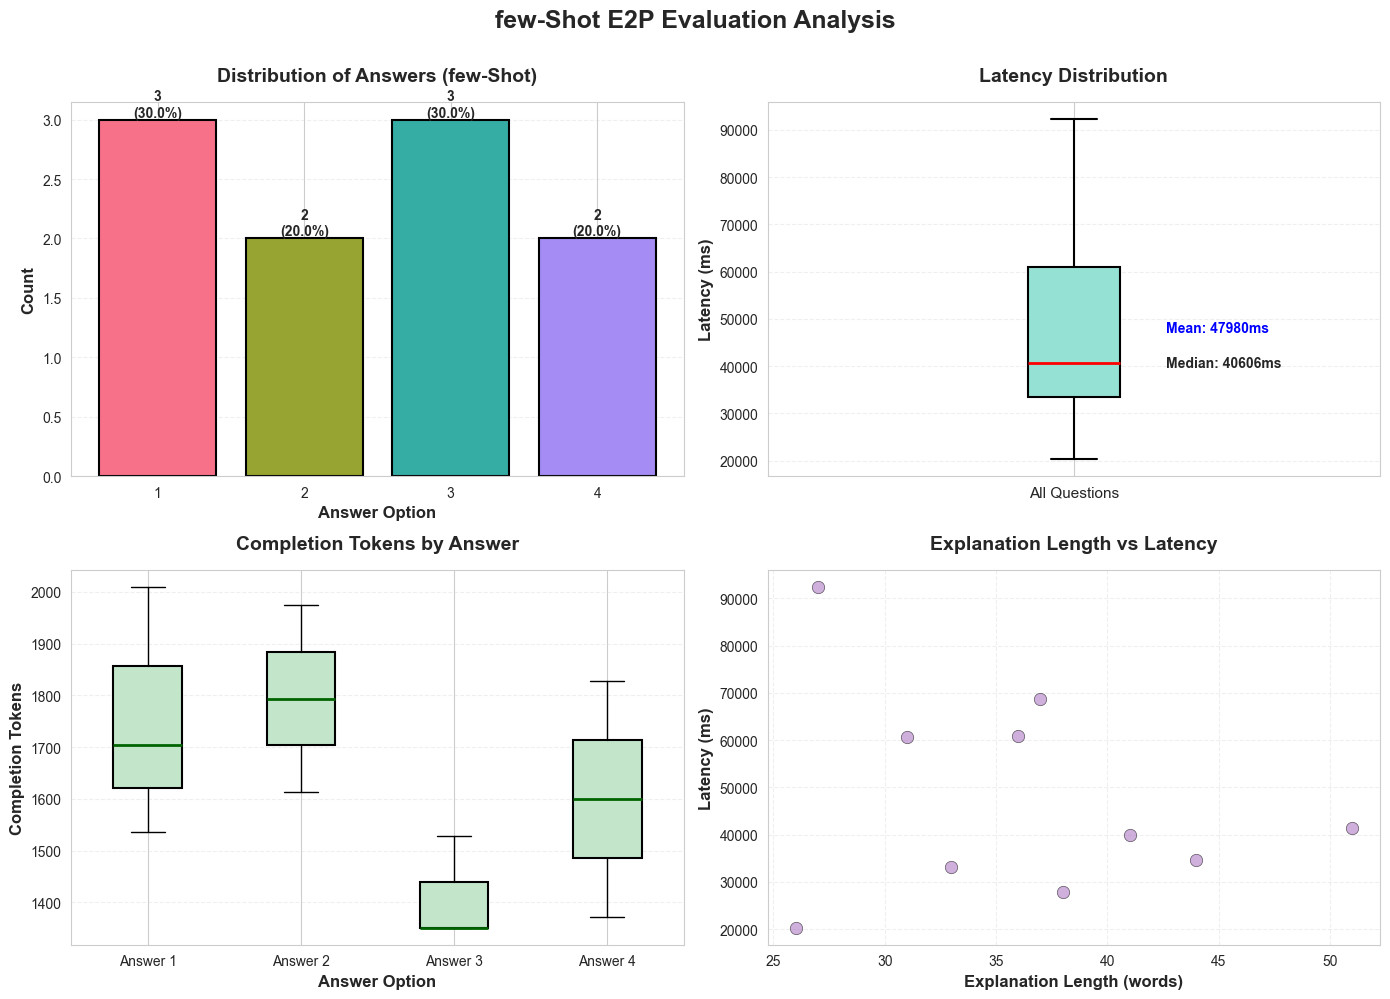


📊 Generating correlation heatmap...
   ✅ Heatmap saved: correlation_heatmap_few_shot.png


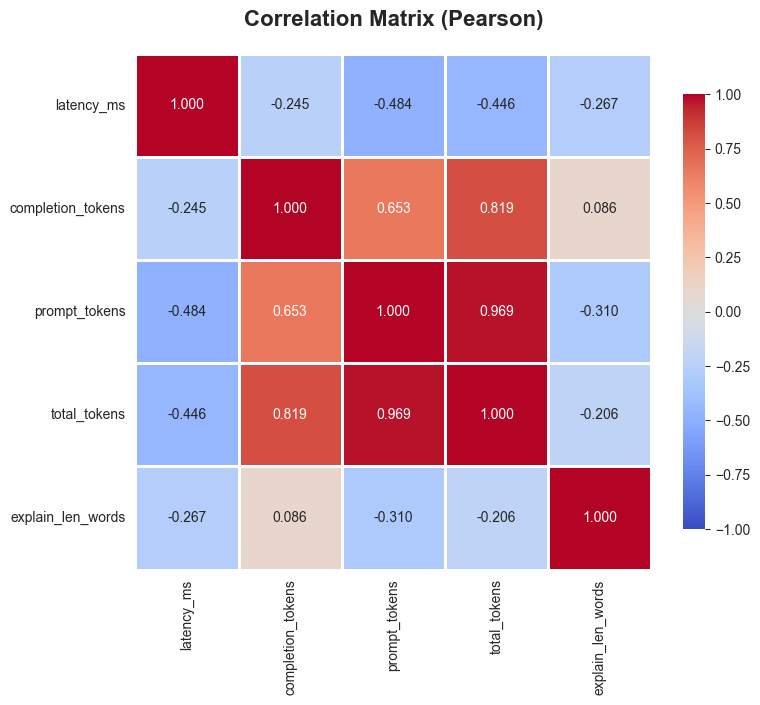


📊 Generating latency timeline...
   ✅ Timeline saved: latency_timeline_few_shot.png


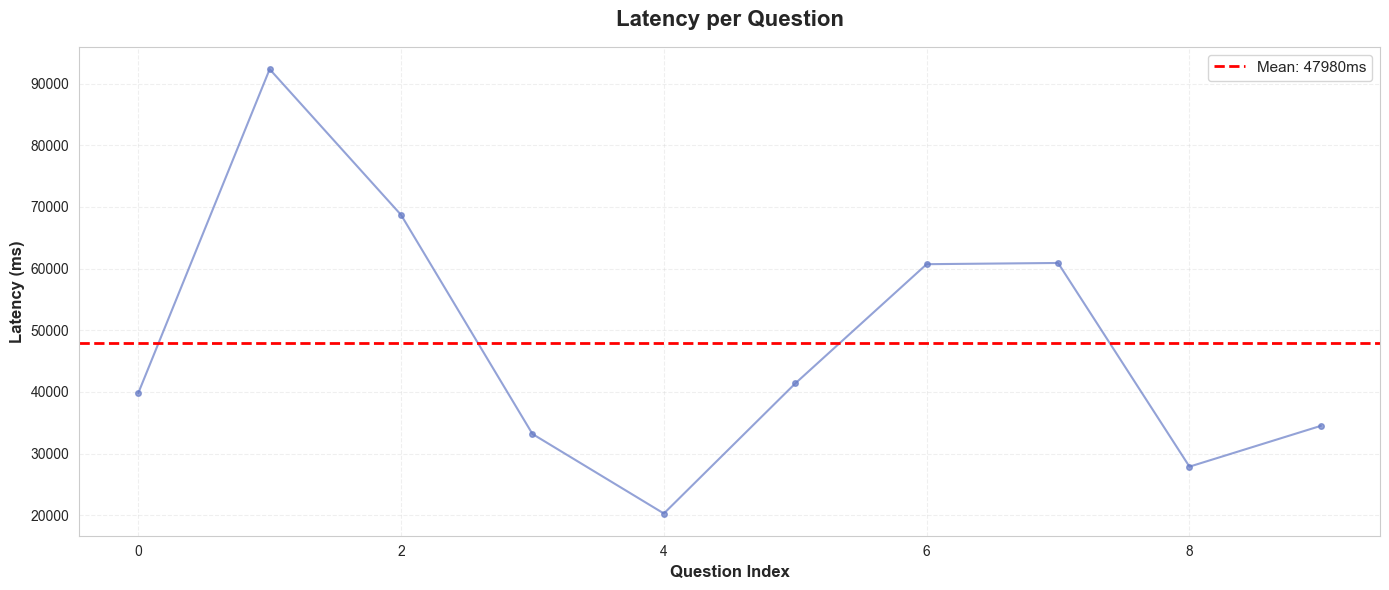

   ✅ Saved: tokens_vs_latency.png
   ✅ Saved: explain_len_vs_tokens.png

✅ All visualizations generated successfully!


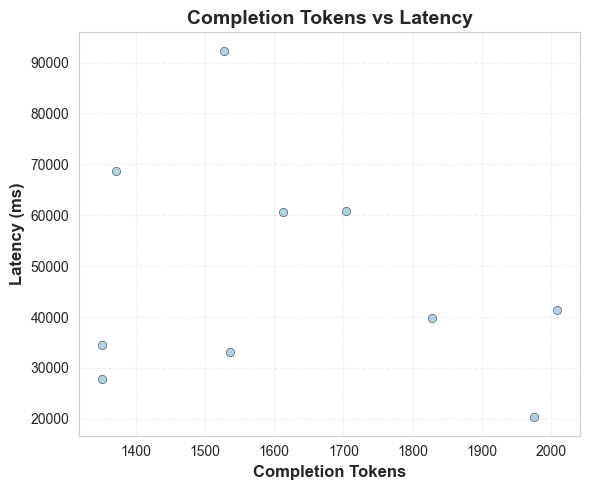

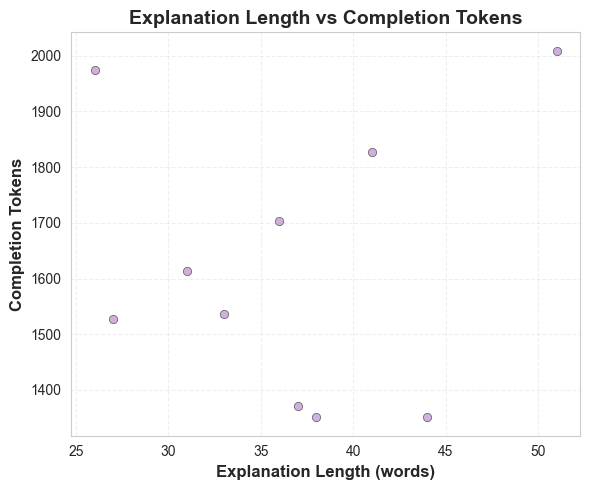

In [12]:
# تنظیمات نمایش
plt.rcParams['font.family'] = 'Arial'
sns.set_style("whitegrid")
sns.set_palette("husl")

print("\n" + "="*70)
print("📊 Generating Visualizations")
print("="*70)

fig = plt.figure(figsize=(14, 10))

# ==================== نمودار 1: توزیع پاسخ نهایی ====================
ax1 = plt.subplot(2, 2, 1)
if 'answer' in results.columns and results['answer'].notna().any():
    answer_counts = results['answer'].dropna().astype(str).value_counts().sort_index()
    colors = sns.color_palette("husl", len(answer_counts))
    bars = ax1.bar(answer_counts.index.astype(str), answer_counts.values,
                   color=colors, edgecolor='black', linewidth=1.5)

    total_n = len(results)
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}\n({height/total_n*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax1.set_title('Distribution of Answers (few-Shot)', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Answer Option', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
else:
    ax1.text(0.5, 0.5, 'No answers', ha='center', va='center', fontsize=12)
    ax1.axis('off')

# ==================== نمودار 2: Boxplot Latency ====================
ax2 = plt.subplot(2, 2, 2)
if 'latency_ms' in results.columns and results['latency_ms'].notna().any():
    valid_latency = results['latency_ms'].dropna()
    ax2.boxplot(valid_latency, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#95E1D3', edgecolor='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5),
                medianprops=dict(color='red', linewidth=2))

    ax2.set_title('Latency Distribution', fontsize=14, fontweight='bold', pad=15)
    ax2.set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
    ax2.set_xticklabels(['All Questions'], fontsize=11)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    median_lat = valid_latency.median()
    mean_lat = valid_latency.mean()
    ax2.text(1.15, median_lat, f'Median: {median_lat:.0f}ms', fontsize=10, fontweight='bold', va='center')
    ax2.text(1.15, mean_lat, f'Mean: {mean_lat:.0f}ms', fontsize=10, fontweight='bold', va='center', color='blue')
else:
    ax2.text(0.5, 0.5, 'No latency data', ha='center', va='center', fontsize=12)
    ax2.axis('off')

# ==================== نمودار 3: Completion Tokens by Answer ====================
ax3 = plt.subplot(2, 2, 3)
if {'completion_tokens', 'answer'}.issubset(results.columns):
    grp = results.dropna(subset=['completion_tokens', 'answer']).copy()
    if len(grp) > 0:
        ans_order = sorted(grp['answer'].astype(str).unique())
        data = [grp.loc[grp['answer'].astype(str) == a, 'completion_tokens'] for a in ans_order]
        labels = [f'Answer {a}' for a in ans_order]
        ax3.boxplot(data, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='#C3E6CB', edgecolor='black', linewidth=1.5),
                    medianprops=dict(color='darkgreen', linewidth=2))
        ax3.set_title('Completion Tokens by Answer', fontsize=14, fontweight='bold', pad=15)
        ax3.set_xlabel('Answer Option', fontsize=12, fontweight='bold')
        ax3.set_ylabel('Completion Tokens', fontsize=12, fontweight='bold')
        ax3.grid(axis='y', alpha=0.3, linestyle='--')
    else:
        ax3.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
        ax3.axis('off')
else:
    ax3.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
    ax3.axis('off')

# ==================== نمودار 4: Scatter explain_len_words vs latency ====================
ax4 = plt.subplot(2, 2, 4)
if {'explain_len_words', 'latency_ms'}.issubset(results.columns):
    valid_data = results.dropna(subset=['explain_len_words', 'latency_ms']).copy()
    if len(valid_data) > 0:
        sc = ax4.scatter(valid_data['explain_len_words'], valid_data['latency_ms'],
                         alpha=0.6, color='#AF7AC5', edgecolors='black', linewidths=0.5, s=80)
        ax4.set_title('Explanation Length vs Latency', fontsize=14, fontweight='bold', pad=15)
        ax4.set_xlabel('Explanation Length (words)', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
        ax4.grid(alpha=0.3, linestyle='--')
    else:
        ax4.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', fontsize=12)
        ax4.axis('off')
else:
    ax4.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', fontsize=12)
    ax4.axis('off')

# ==================== تنظیمات کلی ====================
plt.suptitle('few-Shot E2P Evaluation Analysis', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])

viz_filename = 'visualizations_few_shot.png'
plt.savefig(viz_filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"   ✅ Visualization saved: {viz_filename}")
plt.show()

# ==================== نمودار 5: Heatmap همبستگی ====================
print("\n📊 Generating correlation heatmap...")
fig2, ax5 = plt.subplots(figsize=(8, 7))
numeric_cols = [c for c in [
    'latency_ms', 'completion_tokens', 'prompt_tokens',
    'total_tokens', 'explain_len_words'
] if c in results.columns]

if len(numeric_cols) >= 2:
    corr_data = results[numeric_cols].corr(method='pearson')
    sns.heatmap(corr_data, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=2, cbar_kws={"shrink": 0.8},
                ax=ax5, vmin=-1, vmax=1)
    ax5.set_title('Correlation Matrix (Pearson)', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    heatmap_filename = 'correlation_heatmap_few_shot.png'
    plt.savefig(heatmap_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"   ✅ Heatmap saved: {heatmap_filename}")
    plt.show()
else:
    print("   ⚠️  Not enough numeric columns for correlation matrix")

# ==================== نمودار 6: Timeline latency ====================
print("\n📊 Generating latency timeline...")
fig3, ax6 = plt.subplots(figsize=(14, 6))
if 'latency_ms' in results.columns and results['latency_ms'].notna().any():
    valid_latency_timeline = results['latency_ms'].dropna()
    ax6.plot(valid_latency_timeline.index, valid_latency_timeline,
             marker='o', linestyle='-', linewidth=1.5, markersize=4,
             color='#667BC6', alpha=0.7)
    ax6.axhline(valid_latency_timeline.mean(),
                color='red', linestyle='--', linewidth=2,
                label=f'Mean: {valid_latency_timeline.mean():.0f}ms')
    ax6.set_title('Latency per Question', fontsize=16, fontweight='bold', pad=15)
    ax6.set_xlabel('Question Index', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
    ax6.legend(fontsize=11)
    ax6.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    timeline_filename = 'latency_timeline_few_shot.png'
    plt.savefig(timeline_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"   ✅ Timeline saved: {timeline_filename}")
    plt.show()
else:
    print("   ⚠️  No latency data")

# ==================== نمودار 7: Completion Tokens vs Latency ====================
if {'completion_tokens', 'latency_ms'}.issubset(results.columns):
    sub = results.dropna(subset=['completion_tokens', 'latency_ms'])
    if len(sub) > 0:
        plt.figure(figsize=(6, 5))
        plt.scatter(sub['completion_tokens'], sub['latency_ms'], alpha=0.6, color='#7FB3D5',
                    edgecolors='black', linewidths=0.5)
        plt.title('Completion Tokens vs Latency', fontsize=14, fontweight='bold')
        plt.xlabel('Completion Tokens', fontsize=12, fontweight='bold')
        plt.ylabel('Latency (ms)', fontsize=12, fontweight='bold')
        plt.grid(alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.savefig('tokens_vs_latency.png', dpi=300, bbox_inches='tight', facecolor='white')
        print("   ✅ Saved: tokens_vs_latency.png")

# ==================== نمودار 8: Explanation Length vs Completion Tokens ====================
if {'explain_len_words', 'completion_tokens'}.issubset(results.columns):
    sub = results.dropna(subset=['explain_len_words', 'completion_tokens'])
    if len(sub) > 0:
        plt.figure(figsize=(6, 5))
        plt.scatter(sub['explain_len_words'], sub['completion_tokens'], alpha=0.6,
                    color='#AF7AC5', edgecolors='black', linewidths=0.5)
        plt.title('Explanation Length vs Completion Tokens', fontsize=14, fontweight='bold')
        plt.xlabel('Explanation Length (words)', fontsize=12, fontweight='bold')
        plt.ylabel('Completion Tokens', fontsize=12, fontweight='bold')
        plt.grid(alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.savefig('explain_len_vs_tokens.png', dpi=300, bbox_inches='tight', facecolor='white')
        print("   ✅ Saved: explain_len_vs_tokens.png")

print("\n" + "="*70)
print("✅ All visualizations generated successfully!")
print("="*70)